<a href="https://colab.research.google.com/github/sujal003-hue/Upgrade-Capstone-Project/blob/main/Loan_approval_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# **Loading Our Dataset**

In [ ]:
df = pd.read_csv('/content/loans.csv') # Step 1: Reload df to ensure original state

# **Display Top 5 Rows Of Our Dataset**

In [ ]:
df.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


# **Display Last 5 Rows Of Our Dataset**

In [ ]:
df.tail()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
438,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
439,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
440,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65
441,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50
442,26945,home,3643,0,11434,2010-03-24,2011-12-22,0.13


# **Get Information About Our Dataset Like Total Number Of Rows, Columns, Datatype Of Each Column And Memory Requriment**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   client_id    443 non-null    int64  
 1   loan_type    443 non-null    object 
 2   loan_amount  443 non-null    int64  
 3   repaid       443 non-null    int64  
 4   loan_id      443 non-null    int64  
 5   loan_start   443 non-null    object 
 6   loan_end     443 non-null    object 
 7   rate         443 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 27.8+ KB


# **Check The Null Values In Our Dataset**

In [ ]:
df.isnull().sum()

,0
client_id,0
loan_type,0
loan_amount,0
repaid,0
loan_id,0
loan_start,0
loan_end,0
rate,0


# **Statistical Measure Of Our Dataset**

In [ ]:
df.describe()

,client_id,loan_amount,repaid,loan_id,rate
count,443.00,443.00,443.00,443.00,443.00
mean,38911.06,7982.31,0.53,11017.10,3.22
std,7768.68,4172.89,0.50,581.83,2.40
min,25707.00,559.00,0.00,10009.00,0.01
25%,32885.00,4232.50,0.00,10507.50,1.22
50%,39505.00,8320.00,1.00,11033.00,2.78
75%,46109.00,11739.00,1.00,11526.00,4.75
max,49624.00,14971.00,1.00,11991.00,12.62


In [ ]:
df['loan_id'].count()

np.int64(443)

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
df.columns.str.strip()

Index(['client_id', 'loan_type', 'loan_amount', 'repaid', 'loan_id',
       'loan_start', 'loan_end', 'rate'],
      dtype='object')

In [ ]:
df['loan_type'].unique()

array(['home', 'credit', 'cash', 'other'], dtype=object)

In [ ]:
df['loan_id'] = df['loan_id'].astype(str)

# **Data Visualization Through Barplot**

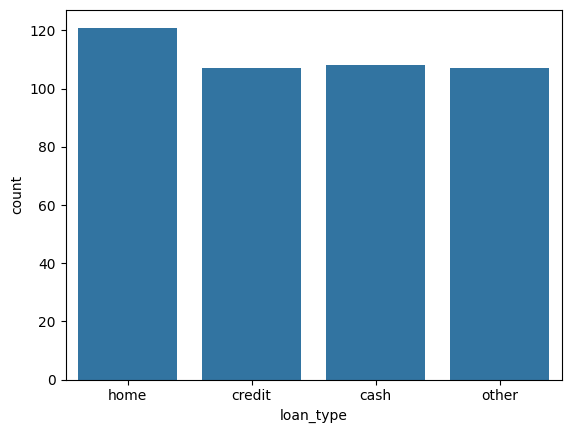

In [ ]:
sns.countplot(x = 'loan_type', data=df)
plt.show()

**Check The "Repaid" Column**

In [ ]:
df['repaid'].value_counts()

,count
repaid,
1,237
0,206


**Making Change In "Repaid" Column Like "Approved" And "Not Approved"**

In [ ]:
df['repaid'] = df['repaid'].map({0: 'no', 1: 'yes'})
df['repaid'] = df['repaid'].map({'yes': 'Approved', 'no': 'Not Approved'})
display(df['repaid'].value_counts())

,count
repaid,
Approved,237
Not Approved,206


**Checking The Percentage Of "Approved" And "Not Approved"**

In [ ]:
df['repaid'] = df['repaid'].map({0: 'no', 1: 'yes'})
df['repaid'] = df['repaid'].map({'yes': 'Approved', 'no': 'Not Approved'})

rep_status = df['repaid'].value_counts(normalize=True) * 100
display(rep_status)

,proportion
repaid,
Approved,53.50
Not Approved,46.50


**Data Visualization Through Barplot Of "Repaid" Column Includes "Approved" And "Not Approved"**

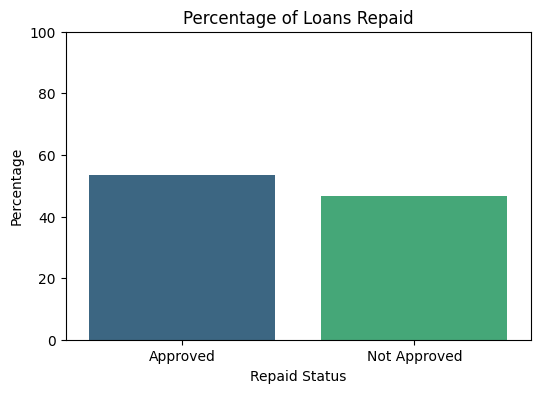

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x=rep_status.index, y=rep_status.values, palette='viridis', hue=rep_status.index, legend=False)
plt.title('Percentage of Loans Repaid')
plt.xlabel('Repaid Status')
plt.ylabel('Percentage')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100
plt.show()

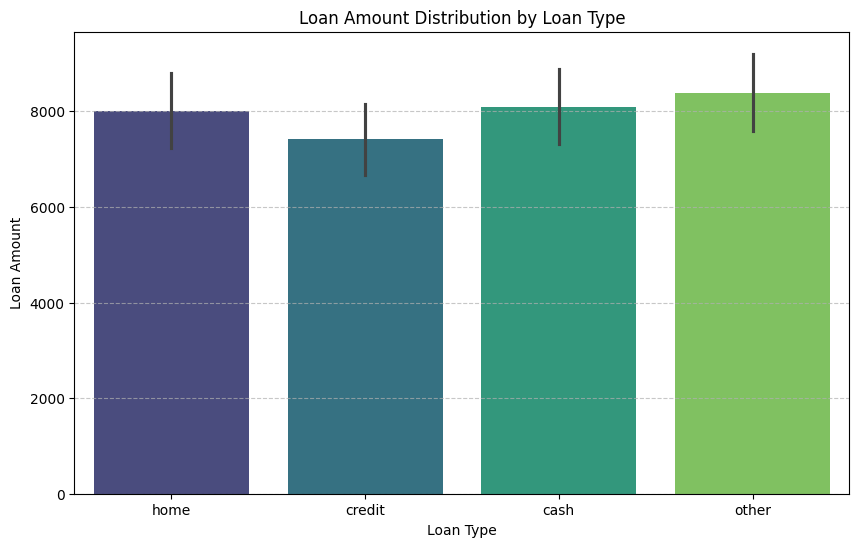

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='loan_type', y='loan_amount', data=df, palette='viridis', hue='loan_type', legend=False)
plt.title('Loan Amount Distribution by Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Loan Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Data Visualization Through Histogram**

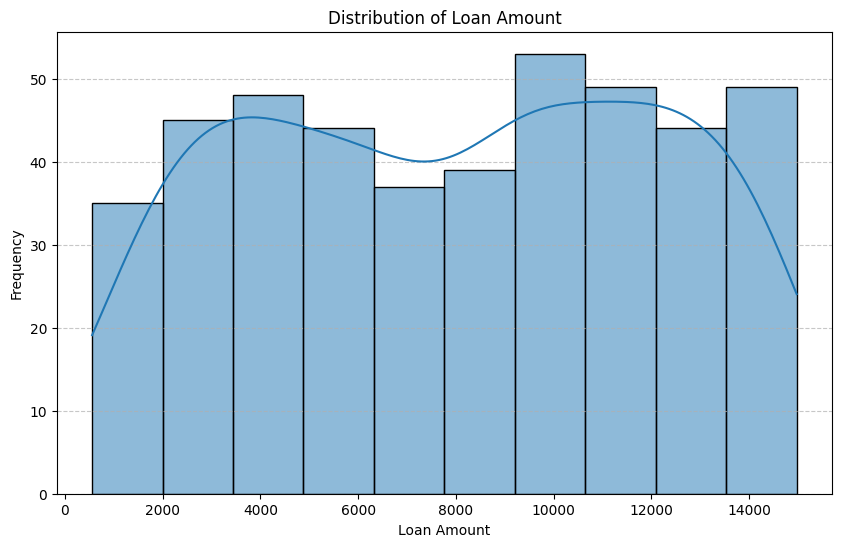

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amount'], bins=10, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Data Visualization Through Heatmap**

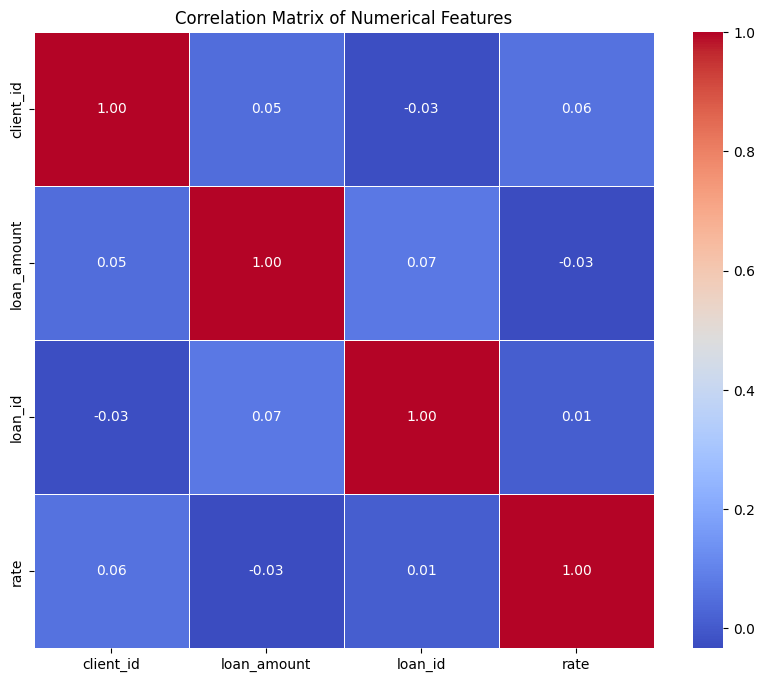

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **Display Top 5 Rows Of Our Dataset**

In [ ]:
df.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,Not Approved,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,Not Approved,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,Approved,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,Approved,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,Approved,11415,2010-07-07,2012-05-21,3.13


# **Label Encoder**

In [ ]:
l = LabelEncoder()
df['loan_type'] = l.fit_transform(df['loan_type'])
df['repaid'] = l.fit_transform(df['repaid'])

In [ ]:
pd.get_dummies(df, columns = ['loan_type'])

,client_id,loan_amount,repaid,loan_id,loan_start,loan_end,rate,loan_type_0,loan_type_1,loan_type_2,loan_type_3
0,46109,13672,1,10243,2002-04-16,2003-12-20,2.15,False,False,True,False
1,46109,9794,1,10984,2003-10-21,2005-07-17,1.25,False,True,False,False
2,46109,12734,0,10990,2006-02-01,2007-07-05,0.68,False,False,True,False
3,46109,12518,0,10596,2010-12-08,2013-05-05,1.24,True,False,False,False
4,46109,14049,0,11415,2010-07-07,2012-05-21,3.13,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
438,26945,12963,1,10330,2001-11-26,2004-06-11,2.46,False,False,False,True
439,26945,1728,0,10248,2004-01-27,2005-06-21,5.27,False,True,False,False
440,26945,9329,1,10154,2001-12-17,2004-07-22,5.65,False,False,False,True
441,26945,4197,1,10333,2003-10-16,2005-07-10,4.50,False,False,True,False


# **Standard Scaler**

In [ ]:
scaler = StandardScaler()

In [ ]:
num_cols = ['client_id', 'loan_type','loan_amount','loan_id','rate']

In [ ]:
X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
df

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,0.93,0.44,1.37,1.07,-1.33,2002-04-16,2003-12-20,-0.45
1,0.93,-0.46,0.43,1.07,-0.06,2003-10-21,2005-07-17,-0.82
2,0.93,0.44,1.14,-0.93,-0.05,2006-02-01,2007-07-05,-1.06
3,0.93,-1.37,1.09,-0.93,-0.72,2010-12-08,2013-05-05,-0.83
4,0.93,-0.46,1.46,-0.93,0.68,2010-07-07,2012-05-21,-0.04
...,...,...,...,...,...,...,...,...
438,-1.54,1.35,1.19,1.07,-1.18,2001-11-26,2004-06-11,-0.32
439,-1.54,-0.46,-1.50,-0.93,-1.32,2004-01-27,2005-06-21,0.86
440,-1.54,1.35,0.32,1.07,-1.49,2001-12-17,2004-07-22,1.02
441,-1.54,0.44,-0.91,1.07,-1.18,2003-10-16,2005-07-10,0.54


In [ ]:
y = df['repaid'].copy()
X = df.drop(['repaid', 'loan_start', 'loan_end'], axis = 1)

In [ ]:
y

,repaid
0,1.07
1,1.07
2,-0.93
3,-0.93
4,-0.93
...,...
438,1.07
439,-0.93
440,1.07
441,1.07


# **Store Feature Matrix In X Response (Target) In Vector y**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 30)

models = {"Logistic Regression" : LogisticRegression(max_iter = 1000),
"Decision Tree" : DecisionTreeClassifier(),
"Random Forest" : RandomForestClassifier()
}

print("Model Accuracies:")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, preds):.4f}")

Model Accuracies:
Logistic Regression: 0.4719
Decision Tree: 0.5169
Random Forest: 0.4157


**So, futher we use Decision Tree because it has highest score.**

In [ ]:
X = df.drop(['repaid', 'loan_start', 'loan_end'], axis = 1)
y = df['repaid']

# **Splitting The Dataset Into Train Test And Test Set**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 30, stratify = y)

# **Decision Tree Classifier**

In [ ]:
df_model = DecisionTreeClassifier(max_depth = 10, random_state=30)

**Fits The Model**

In [ ]:
df_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=30)

**Makes Predictions**

In [ ]:
df_preds = df_model.predict(X_test)

In [ ]:
print(f"Decision Tree Model Accuracy: {accuracy_score(y_test, df_preds):.4f}")
print("Classification Report:")
print(classification_report(y_test, df_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, df_preds))

Decision Tree Model Accuracy: 0.5281
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.44      0.46        41
           1       0.56      0.60      0.58        48

    accuracy                           0.53        89
   macro avg       0.52      0.52      0.52        89
weighted avg       0.52      0.53      0.53        89

Confusion Matrix:
[[18 23]
 [19 29]]


# **Conclusion**

**To conclude by saying that firstly, we load our dataset, we perform explantory data analysis, we check the name and number of rows and columns, statistical measure of dataset and also check the null values. We also do splits the dataset into train set and test test, then we uses various models like Logistic Regression, Decision Tree Classifier and Random Forest which heips to predicts the accuracy score as above mentioned.**